In [1]:
import pandas as pd
from PIL.DdsImagePlugin import item
from hypothesis.extra.pandas import columns
from pandas.conftest import axis
from sklearn import preprocessing
from sklearn.base import BaseEstimator, TransformerMixin

from src.data_loader import data_loader

houses = data_loader()
houses_raw = houses.copy()
houses_added_features = houses_raw.copy()

## Step 1:
First, I need to split the dataset into training and test sets. I used stratified sampling to select examples that are representative of the entire population.

In [2]:
houses_raw['OverallQual'].describe()

count    1460.000000
mean        6.099315
std         1.382997
min         1.000000
25%         5.000000
50%         6.000000
75%         7.000000
max        10.000000
Name: OverallQual, dtype: float64

In [3]:
import numpy as np

houses_raw["QualCat"] = pd.cut(houses_raw["OverallQual"],
                               bins=[0, 2, 4, 6, 8, 10],
                               labels=[1, 2, 3,4, 5])

<Axes: xlabel='QualCat'>

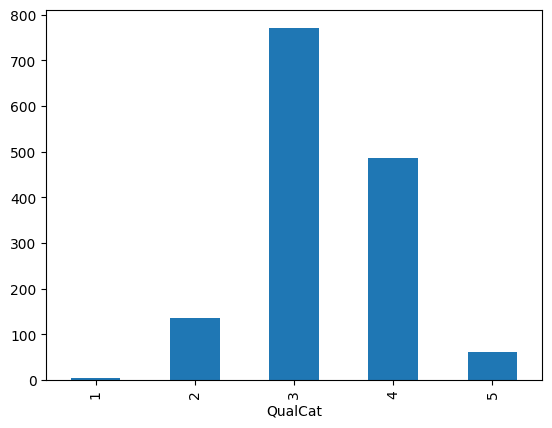

In [4]:
houses_raw['QualCat'].value_counts().sort_index(ascending=True).plot(kind='bar')

In [5]:
houses_raw['QualCat'].value_counts().sort_index()

QualCat
1      5
2    136
3    771
4    487
5     61
Name: count, dtype: int64

In [6]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(houses_raw, stratify=houses_raw['QualCat'], test_size=0.2, random_state=42)

After spliting data I need to remove 'QualCat' from both tranning and test tests. This feature contains crucial information about the target and must not be included during traning.

In [7]:
for set_ in train_set, test_set, houses_raw:
    set_.drop(['QualCat', 'Id', 'SalePrice'], axis=1, inplace=True)

In [8]:
houses_raw.head(10)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal
5,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal
6,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal
7,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,Shed,350,11,2009,WD,Normal
8,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml
9,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,Corner,...,0,0,NaN,NaN,NaN,0,1,2008,WD,Normal


In [9]:
houses_raw['Fence'].value_counts()

Fence
MnPrv    157
GdPrv     59
GdWo      54
MnWw      11
Name: count, dtype: int64

In [10]:
numeric_data = houses_raw.select_dtypes(np.number)
numeric_data

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,548,0,61,0,0,0,0,0,2,2008
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,460,298,0,0,0,0,0,0,5,2007
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,608,0,42,0,0,0,0,0,9,2008
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,642,0,35,272,0,0,0,0,2,2006
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,836,192,84,0,0,0,0,0,12,2008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,62.0,7917,6,5,1999,2000,0.0,0,0,...,460,0,40,0,0,0,0,0,8,2007
1456,20,85.0,13175,6,6,1978,1988,119.0,790,163,...,500,349,0,0,0,0,0,0,2,2010
1457,70,66.0,9042,7,9,1941,2006,0.0,275,0,...,252,0,60,0,0,0,0,2500,5,2010
1458,20,68.0,9717,5,6,1950,1996,0.0,49,1029,...,240,366,0,112,0,0,0,0,4,2010


## Step 2:
I start modifications of the data set. I will fill missing values with transformers methods. Some features are not important for the model, so I will drop them.


First I can add some features which might be helpful and make our data more descriptive.

In [11]:
houses_added_features.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [12]:
#total area of the house
houses_added_features["TotalSF"] = houses_added_features["TotalBsmtSF"] + houses_added_features["1stFlrSF"] + houses_added_features["2ndFlrSF"]

#house age
houses_added_features["HouseAge"] = houses_added_features["YrSold"] - houses_added_features["YearBuilt"]
houses_added_features["RemodelAge"] = houses_added_features["YrSold"] - houses_added_features["YearRemodAdd"]
houses_added_features["WasRemodeled"] = (houses_added_features["YearBuilt"] != houses_added_features["YearRemodAdd"]).astype(int)

#łazienki
houses_added_features["TotalBath"] = (houses_added_features["FullBath"] +
                                       houses_added_features["HalfBath"] * 0.5 +
                                       houses_added_features["BsmtFullBath"] +
                                       houses_added_features["BsmtHalfBath"] * 0.5)

#garaż
houses_added_features["GarageAreaPerCar"] = houses_added_features["GarageArea"] / (houses_added_features["GarageCars"] + 1)

#udogodnienia
houses_added_features["HasPool"] = (houses_added_features["PoolArea"] > 0).astype(int)
houses_added_features["HasBasement"] = (houses_added_features["TotalBsmtSF"] > 0).astype(int)
houses_added_features["HasGarage"] = (houses_added_features["GarageArea"] > 0).astype(int)
houses_added_features["HasFireplace"] = (houses_added_features["Fireplaces"] > 0).astype(int)

#jakość nieruchomości
houses_added_features["QualXSF"] = houses_added_features["OverallQual"] * houses_added_features["GrLivArea"]

In [13]:
houses_added_features[["TotalSF","HouseAge","RemodelAge","WasRemodeled","TotalBath","GarageAreaPerCar","HasPool","HasBasement","HasGarage","HasFireplace","QualXSF"]]

,TotalSF,HouseAge,RemodelAge,WasRemodeled,TotalBath,GarageAreaPerCar,HasPool,HasBasement,HasGarage,HasFireplace,QualXSF
0,2566,5,5,0,3.5,182.666667,0,1,1,0,11970
1,2524,31,31,0,2.5,153.333333,0,1,1,1,7572
2,2706,7,6,1,3.5,202.666667,0,1,1,1,12502
3,2473,91,36,1,2.0,160.500000,0,1,1,1,12019
4,3343,8,8,0,3.5,209.000000,0,1,1,1,17584
...,...,...,...,...,...,...,...,...,...,...,...
1455,2600,8,7,1,2.5,153.333333,0,1,1,1,9882
1456,3615,32,22,1,3.0,166.666667,0,1,1,1,12438
1457,3492,69,4,1,2.0,126.000000,0,1,1,1,16380
1458,2156,60,14,1,2.0,120.000000,0,1,1,0,5390


<Axes: ylabel='None'>

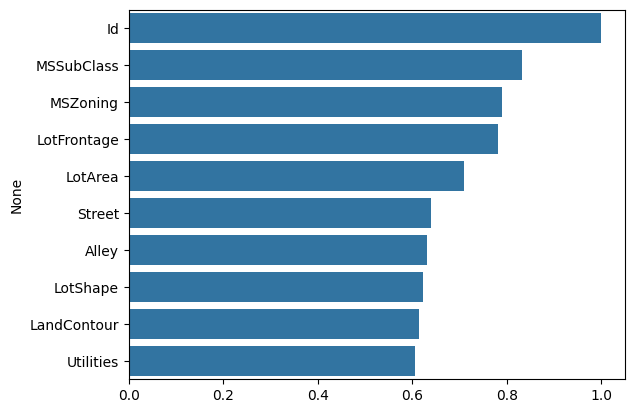

In [14]:

import seaborn as sns

corr_matrix = houses_added_features.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
sns.barplot(x = corr_matrix.values[:10], y = houses_added_features.columns[:10])


Now I am imputing NaN values. I know which columns has numeric and string values from the `01_data_analize` notebook.



<class 'pandas.DataFrame'>


RangeIndex: 1460 entries, 0 to 1459


 #   Column        Non-Null Count  Dtype


---  ------        --------------  -----


 0   PoolQC        7 non-null      str


 1   MiscFeature   54 non-null     str


 2   Alley         91 non-null     str


 3   Fence         281 non-null    str


 4   MasVnrType    588 non-null    str


 5   FireplaceQu   770 non-null    str


 6   LotFrontage   1201 non-null   float64


 7   GarageType    1379 non-null   str


 8   GarageFinish  1379 non-null   str


 9   GarageYrBlt   1379 non-null   float64


dtypes: float64(2), str(8)


memory usage: 114.2 KB

In [15]:
from sklearn.impute import SimpleImputer

lotFrontageImputer = SimpleImputer(fill_value= houses_raw['LotFrontage'].min(),strategy='constant')
lotFrontageImputer.fit(houses_raw[['LotFrontage']])
houses_raw['LotFrontage'] = lotFrontageImputer.transform(houses_raw[['LotFrontage']])

fast check

In [16]:
houses_raw['LotFrontage'].isnull().sum()

np.int64(0)

gitarra

In [17]:
houses_raw['GarageYrBlt'].sample(15)

893     1954.0
1416    1971.0
271     1954.0
15      1991.0
105     2003.0
254     1957.0
1300    1999.0
265     1981.0
1103    1954.0
211     2009.0
566     2005.0
431        NaN
1424    1970.0
626     1960.0
352     1941.0
Name: GarageYrBlt, dtype: float64

In this case I shouldn't imput 0 in the case when garage is not present. This may affect system during traning.

In my opinion the best solution is delete this feature. The feature is not crucial when yr of build the garage is almost the same as yr of building home and in many features info are conected.

In [18]:
train_set.drop('GarageYrBlt', axis=1, inplace=True)
test_set.drop('GarageYrBlt', axis=1, inplace=True)
houses_raw.drop('GarageYrBlt', axis=1, inplace=True)

In [19]:
cols_to_drop = ['GarageYrBlt', 'Id'] # for the feature

Rest of NaN means lack of thing in property. I can use additional desc for NaN.

In [20]:
string_type_inputer = SimpleImputer(strategy='constant', fill_value='miss')
string_type_inputer.set_output(transform="pandas")

cat_cols = houses_raw.select_dtypes(include=['object']).columns.tolist()

C:\Users\huber\AppData\Local\Temp\ipykernel_13824\3591527286.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = houses_raw.select_dtypes(include=['object']).columns.tolist()


In [21]:
cat_cols

['MSZoning',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'PoolQC',
 'Fence',
 'MiscFeature',
 'SaleType',
 'SaleCondition']

In [22]:
houses_raw[cat_cols] = string_type_inputer.fit_transform(houses_raw[cat_cols])

null_counts = houses_raw.isnull().sum()
print(null_counts[null_counts > 0])

MasVnrArea    8
dtype: int64


I still have 8 features with NaN values.

In [23]:
nulls = houses_raw[houses_raw['MasVnrArea'].isnull()]
nulls

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
234,60,RL,21.0,7851,Pave,miss,Reg,Lvl,AllPub,Inside,...,0,0,miss,miss,miss,0,5,2010,WD,Normal
529,20,RL,21.0,32668,Pave,miss,IR1,Lvl,AllPub,CulDSac,...,0,0,miss,miss,miss,0,3,2007,WD,Alloca
650,60,FV,65.0,8125,Pave,miss,Reg,Lvl,AllPub,Inside,...,0,0,miss,miss,miss,0,5,2008,WD,Normal
936,20,RL,67.0,10083,Pave,miss,Reg,Lvl,AllPub,Inside,...,0,0,miss,miss,miss,0,8,2009,WD,Normal
973,20,FV,95.0,11639,Pave,miss,Reg,Lvl,AllPub,Corner,...,0,0,miss,miss,miss,0,12,2008,New,Partial
977,120,FV,35.0,4274,Pave,Pave,IR1,Lvl,AllPub,Inside,...,0,0,miss,miss,miss,0,11,2007,New,Partial
1243,20,RL,107.0,13891,Pave,miss,Reg,Lvl,AllPub,Inside,...,0,0,miss,miss,miss,0,9,2006,New,Partial
1278,60,RL,75.0,9473,Pave,miss,Reg,Lvl,AllPub,Inside,...,0,0,miss,miss,miss,0,3,2008,WD,Normal


In [24]:
houses_raw.MasVnrArea.count()

np.int64(1452)

In [25]:
houses_raw['MasVnrArea'].info()

<class 'pandas.Series'>
RangeIndex: 1460 entries, 0 to 1459
Series name: MasVnrArea
Non-Null Count  Dtype  
--------------  -----  
1452 non-null   float64
dtypes: float64(1)
memory usage: 11.5 KB


MasVnrArea has type of float so previous imputes do not change it.

In [26]:
float_type_inputer = SimpleImputer(strategy='constant', fill_value=0)
float_type_inputer.set_output(transform="pandas")

houses_raw['MasVnrArea'] = float_type_inputer.fit_transform(houses_raw[['MasVnrArea']])


In [27]:
houses_raw.MasVnrArea.isnull().sum()

np.int64(0)

In [28]:
minYearRemodAdd = houses_raw[['YearRemodAdd', 'YearBuilt']]
filtered = minYearRemodAdd[minYearRemodAdd['YearRemodAdd'] == 1950]
filtered

,YearRemodAdd,YearBuilt
8,1950,1931
9,1950,1939
21,1950,1930
29,1950,1927
30,1950,1920
...,...,...
1408,1950,1910
1412,1950,1949
1416,1950,1885
1427,1950,1945


I can transform features YearRemodAdd where I have value '1950'. I assume that there was not remod so i am going to replace data with year of built.

In [29]:
def transform_years_of_remod(frm):
    frm = frm.copy()
    mask = (frm['YearRemodAdd'] == 1950) & (frm['YearBuilt'] < 1950)
    frm.loc[mask, 'YearRemodAdd'] = frm.loc[mask, 'YearBuilt']
    frm['WasRemodeled'] = (frm['YearRemodAdd'] > frm['YearBuilt']).astype(int)
    return frm

In [30]:
houses_raw = transform_years_of_remod(houses_raw)

In [31]:
houses_raw

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,WasRemodeled
0,60,RL,65.0,8450,Pave,miss,Reg,Lvl,AllPub,Inside,...,0,miss,miss,miss,0,2,2008,WD,Normal,0
1,20,RL,80.0,9600,Pave,miss,Reg,Lvl,AllPub,FR2,...,0,miss,miss,miss,0,5,2007,WD,Normal,0
2,60,RL,68.0,11250,Pave,miss,IR1,Lvl,AllPub,Inside,...,0,miss,miss,miss,0,9,2008,WD,Normal,1
3,70,RL,60.0,9550,Pave,miss,IR1,Lvl,AllPub,Corner,...,0,miss,miss,miss,0,2,2006,WD,Abnorml,1
4,60,RL,84.0,14260,Pave,miss,IR1,Lvl,AllPub,FR2,...,0,miss,miss,miss,0,12,2008,WD,Normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Pave,miss,Reg,Lvl,AllPub,Inside,...,0,miss,miss,miss,0,8,2007,WD,Normal,1
1456,20,RL,85.0,13175,Pave,miss,Reg,Lvl,AllPub,Inside,...,0,miss,MnPrv,miss,0,2,2010,WD,Normal,1
1457,70,RL,66.0,9042,Pave,miss,Reg,Lvl,AllPub,Inside,...,0,miss,GdPrv,Shed,2500,5,2010,WD,Normal,1
1458,20,RL,68.0,9717,Pave,miss,Reg,Lvl,AllPub,Inside,...,0,miss,miss,miss,0,4,2010,WD,Normal,1


In [32]:
houses_raw[houses_raw['YearRemodAdd']  < 1950 ]

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,WasRemodeled
8,50,RM,51.0,6120,Pave,miss,Reg,Lvl,AllPub,Inside,...,0,miss,miss,miss,0,4,2008,WD,Abnorml,0
9,190,RL,50.0,7420,Pave,miss,Reg,Lvl,AllPub,Corner,...,0,miss,miss,miss,0,1,2008,WD,Normal,0
21,45,RM,57.0,7449,Pave,Grvl,Reg,Bnk,AllPub,Inside,...,0,miss,GdPrv,miss,0,6,2007,WD,Normal,0
29,30,RM,60.0,6324,Pave,miss,IR1,Lvl,AllPub,Inside,...,0,miss,miss,miss,0,5,2008,WD,Normal,0
30,70,C (all),50.0,8500,Pave,Pave,Reg,Lvl,AllPub,Inside,...,0,miss,MnPrv,miss,0,7,2008,WD,Normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1408,70,RM,60.0,7740,Pave,miss,Reg,Lvl,AllPub,Inside,...,0,miss,miss,miss,0,6,2010,WD,Normal,0
1412,90,RL,60.0,7200,Pave,miss,Reg,Lvl,AllPub,Inside,...,0,miss,miss,miss,0,6,2009,WD,Normal,0
1416,190,RM,60.0,11340,Pave,miss,Reg,Lvl,AllPub,Inside,...,0,miss,miss,miss,0,4,2010,WD,Normal,0
1427,50,RL,60.0,10930,Pave,Grvl,Reg,Bnk,AllPub,Inside,...,0,miss,miss,miss,0,4,2008,WD,Normal,0


### Step 2.1
I need to transform categorial features into matrix with OneHotEncoder() and OrdinalEncoder

In [33]:

from sklearn.preprocessing import OrdinalEncoder, StandardScaler, MinMaxScaler

ordinal_encoder_cols = [
    'ExterQual', 'ExterCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'HeatingQC', 'KitchenQual', 'FireplaceQu',
    'GarageFinish', 'GarageQual', 'GarageCond',
    'PoolQC', 'Fence', 'LotShape', 'LandSlope', 'Functional',
]

In [34]:
for col in ordinal_encoder_cols:
    print(f"{col:20}: {sorted(houses_raw[col].unique())}")

ExterQual           : ['Ex', 'Fa', 'Gd', 'TA']
ExterCond           : ['Ex', 'Fa', 'Gd', 'Po', 'TA']
BsmtQual            : ['Ex', 'Fa', 'Gd', 'TA', 'miss']
BsmtCond            : ['Fa', 'Gd', 'Po', 'TA', 'miss']
BsmtExposure        : ['Av', 'Gd', 'Mn', 'No', 'miss']
BsmtFinType1        : ['ALQ', 'BLQ', 'GLQ', 'LwQ', 'Rec', 'Unf', 'miss']
BsmtFinType2        : ['ALQ', 'BLQ', 'GLQ', 'LwQ', 'Rec', 'Unf', 'miss']
HeatingQC           : ['Ex', 'Fa', 'Gd', 'Po', 'TA']
KitchenQual         : ['Ex', 'Fa', 'Gd', 'TA']
FireplaceQu         : ['Ex', 'Fa', 'Gd', 'Po', 'TA', 'miss']
GarageFinish        : ['Fin', 'RFn', 'Unf', 'miss']
GarageQual          : ['Ex', 'Fa', 'Gd', 'Po', 'TA', 'miss']
GarageCond          : ['Ex', 'Fa', 'Gd', 'Po', 'TA', 'miss']
PoolQC              : ['Ex', 'Fa', 'Gd', 'miss']
Fence               : ['GdPrv', 'GdWo', 'MnPrv', 'MnWw', 'miss']
LotShape            : ['IR1', 'IR2', 'IR3', 'Reg']
LandSlope           : ['Gtl', 'Mod', 'Sev']
Functional          : ['Maj1', 'Maj2', 'Min1'

In [35]:
ordinal_categories = [
    ['Fa', 'TA', 'Gd', 'Ex'],
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    ['miss', 'Fa', 'TA', 'Gd', 'Ex'],
    ['miss', 'Po', 'Fa', 'TA', 'Gd'],
    ['miss', 'No', 'Mn', 'Av', 'Gd'],
    ['miss', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    ['miss', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    ['Fa', 'TA', 'Gd', 'Ex'],
    ['miss', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    ['miss', 'Unf', 'RFn', 'Fin'],
    ['miss', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    ['miss', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    ['miss', 'Fa', 'Gd', 'Ex'],
    ['miss', 'MnWw', 'MnPrv', 'GdWo', 'GdPrv'],
    ['IR3', 'IR2', 'IR1', 'Reg'],
    ['Sev', 'Mod', 'Gtl'],
    ['Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ'],
]

ordinal_enc = OrdinalEncoder(categories=ordinal_categories,
                             handle_unknown='use_encoded_value',
                            unknown_value=-1)

houses_ord_cat = ordinal_enc.fit_transform(houses_raw[ordinal_encoder_cols])
for col, cats in zip(ordinal_encoder_cols, ordinal_enc.categories_):
    print(f"{col:15}: {list(cats)}")


ExterQual      : ['Fa', 'TA', 'Gd', 'Ex']
ExterCond      : ['Po', 'Fa', 'TA', 'Gd', 'Ex']
BsmtQual       : ['miss', 'Fa', 'TA', 'Gd', 'Ex']
BsmtCond       : ['miss', 'Po', 'Fa', 'TA', 'Gd']
BsmtExposure   : ['miss', 'No', 'Mn', 'Av', 'Gd']
BsmtFinType1   : ['miss', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']
BsmtFinType2   : ['miss', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']
HeatingQC      : ['Po', 'Fa', 'TA', 'Gd', 'Ex']
KitchenQual    : ['Fa', 'TA', 'Gd', 'Ex']
FireplaceQu    : ['miss', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
GarageFinish   : ['miss', 'Unf', 'RFn', 'Fin']
GarageQual     : ['miss', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
GarageCond     : ['miss', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
PoolQC         : ['miss', 'Fa', 'Gd', 'Ex']
Fence          : ['miss', 'MnWw', 'MnPrv', 'GdWo', 'GdPrv']
LotShape       : ['IR3', 'IR2', 'IR1', 'Reg']
LandSlope      : ['Sev', 'Mod', 'Gtl']
Functional     : ['Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ']


In [36]:
houses_ord_cat

array([[2., 2., 3., ..., 3., 2., 6.],
       [1., 2., 3., ..., 3., 2., 6.],
       [2., 2., 3., ..., 2., 2., 6.],
       ...,
       [3., 3., 2., ..., 3., 2., 6.],
       [1., 2., 2., ..., 3., 2., 6.],
       [2., 2., 2., ..., 3., 2., 6.]], shape=(1460, 18))

In [37]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

cat_cols = houses_raw.select_dtypes(include=['str']).columns.tolist()
cat_cols

['MSZoning',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'PoolQC',
 'Fence',
 'MiscFeature',
 'SaleType',
 'SaleCondition']

In [38]:
def remove_ele(cat_list, ordinal_cols):
    x = cat_list.copy()
    for ele in x:
        if ele in ordinal_cols:
            x.remove(ele)
    return x

In [39]:
cat_cols = remove_ele(cat_cols, ordinal_encoder_cols)
cat_cols

['MSZoning',
 'Street',
 'Alley',
 'LandContour',
 'Utilities',
 'LotConfig',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'ExterCond',
 'Foundation',
 'BsmtCond',
 'BsmtFinType1',
 'Heating',
 'CentralAir',
 'Electrical',
 'Functional',
 'GarageType',
 'GarageQual',
 'PavedDrive',
 'Fence',
 'MiscFeature',
 'SaleType',
 'SaleCondition']

In [40]:
for ele in ordinal_encoder_cols:
    if ele in cat_cols:
        print(f"{ele} is in cat_cols")
    else:
        print(f"{ele} is not in cat_cols")

ExterQual is not in cat_cols
ExterCond is in cat_cols
BsmtQual is not in cat_cols
BsmtCond is in cat_cols
BsmtExposure is not in cat_cols
BsmtFinType1 is in cat_cols
BsmtFinType2 is not in cat_cols
HeatingQC is not in cat_cols
KitchenQual is not in cat_cols
FireplaceQu is not in cat_cols
GarageFinish is not in cat_cols
GarageQual is in cat_cols
GarageCond is not in cat_cols
PoolQC is not in cat_cols
Fence is in cat_cols
LotShape is not in cat_cols
LandSlope is not in cat_cols
Functional is in cat_cols


In [41]:

cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(houses_raw[cat_cols])
housing_cat_1hot

array([[0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], shape=(1460, 210))

In [42]:
cat_encoder.categories_

[array(['C (all)', 'FV', 'RH', 'RL', 'RM'], dtype=object),
 array(['Grvl', 'Pave'], dtype=object),
 array(['Grvl', 'Pave', 'miss'], dtype=object),
 array(['Bnk', 'HLS', 'Low', 'Lvl'], dtype=object),
 array(['AllPub', 'NoSeWa'], dtype=object),
 array(['Corner', 'CulDSac', 'FR2', 'FR3', 'Inside'], dtype=object),
 array(['Blmngtn', 'Blueste', 'BrDale', 'BrkSide', 'ClearCr', 'CollgCr',
        'Crawfor', 'Edwards', 'Gilbert', 'IDOTRR', 'MeadowV', 'Mitchel',
        'NAmes', 'NPkVill', 'NWAmes', 'NoRidge', 'NridgHt', 'OldTown',
        'SWISU', 'Sawyer', 'SawyerW', 'Somerst', 'StoneBr', 'Timber',
        'Veenker'], dtype=object),
 array(['Artery', 'Feedr', 'Norm', 'PosA', 'PosN', 'RRAe', 'RRAn', 'RRNe',
        'RRNn'], dtype=object),
 array(['Artery', 'Feedr', 'Norm', 'PosA', 'PosN', 'RRAe', 'RRAn', 'RRNn'],
       dtype=object),
 array(['1Fam', '2fmCon', 'Duplex', 'Twnhs', 'TwnhsE'], dtype=object),
 array(['1.5Fin', '1.5Unf', '1Story', '2.5Fin', '2.5Unf', '2Story',
        'SFoyer', 'SLv

### Step 3.2:
* Feature scaling,
* Transformation features to avoid heavy tail distribution, using `log1p` and `expm1`
* Transformation of multimodal features using RBF (radial basis function)


Firstly I will visualise all numeric features. I want to know distribution of sets.

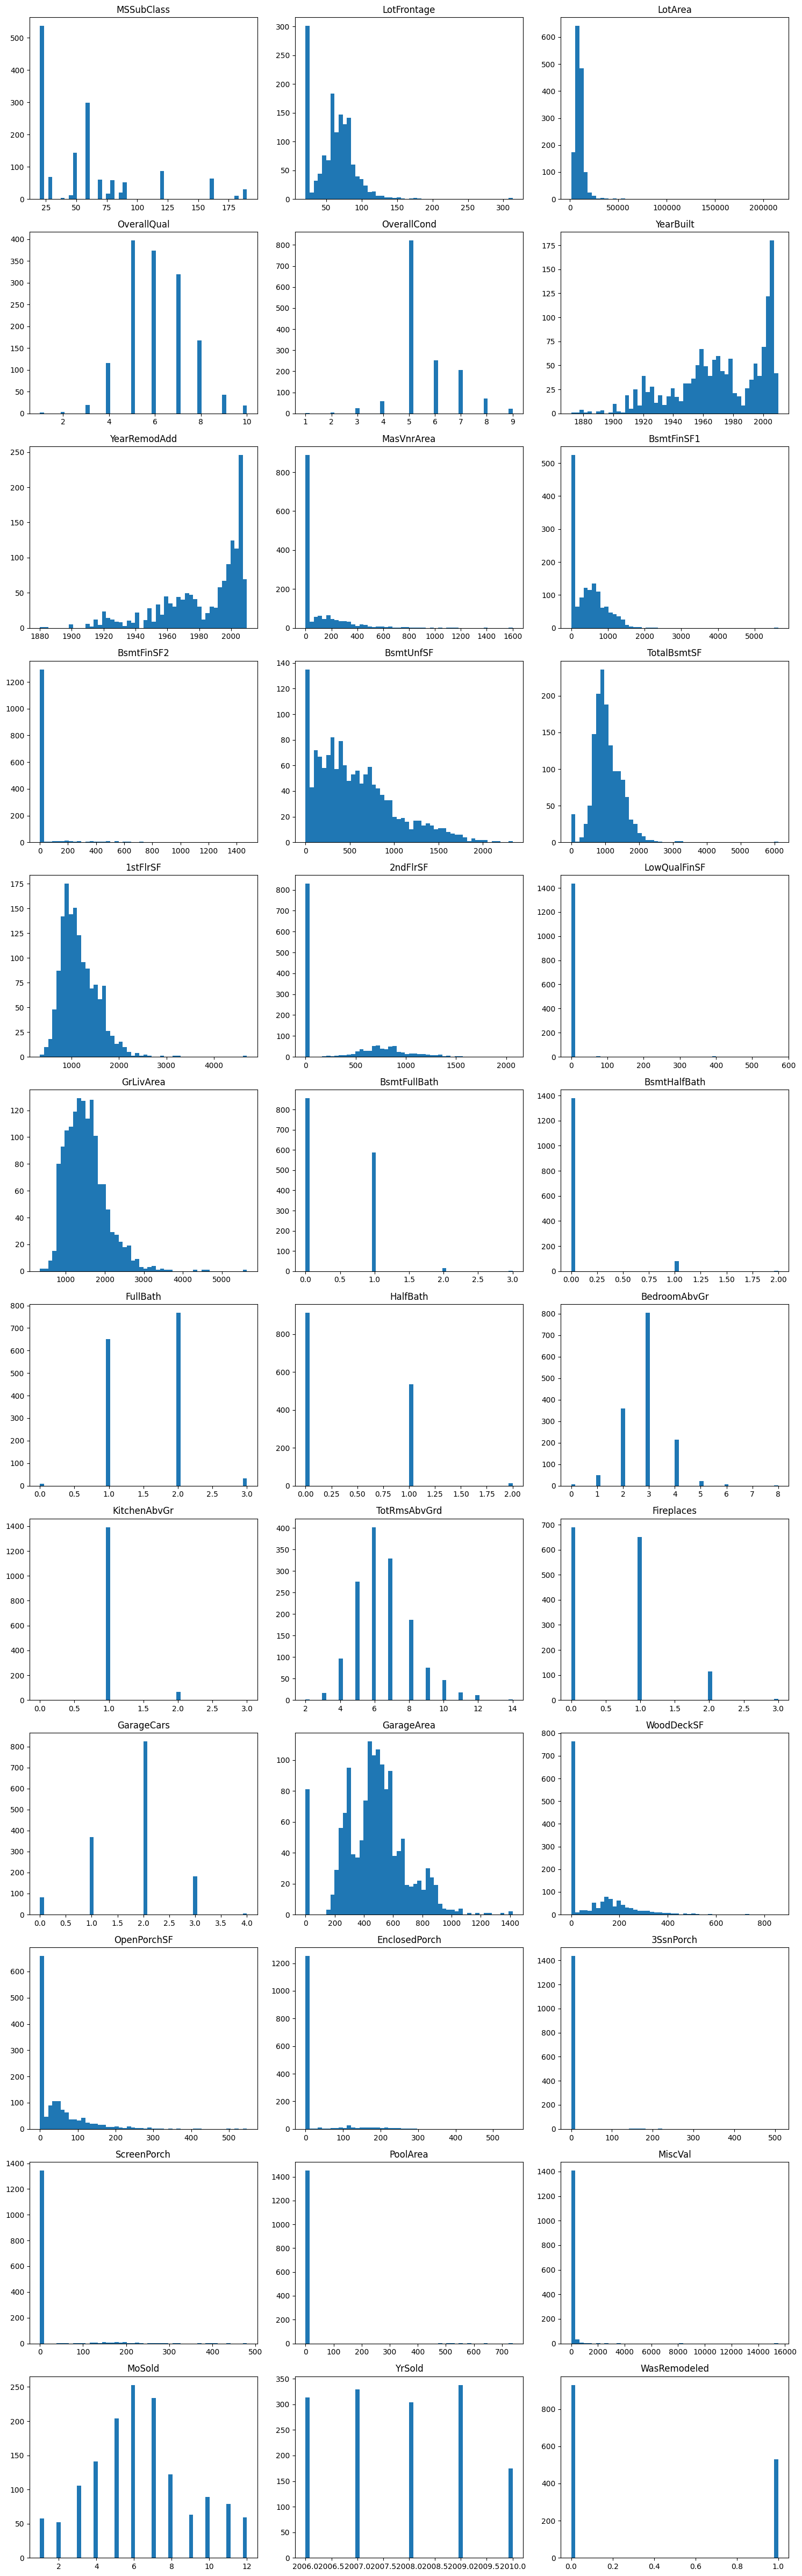

In [43]:
import math
import matplotlib.pyplot as plt

num_features = pd.DataFrame(houses_raw.select_dtypes(include=['float64', 'int64']))
num_features.drop(columns=['Id'], inplace=True, errors='ignore')
n = len(num_features.columns)
cols = 3
rows = math.ceil(n / cols)

fig, ax = plt.subplots(rows, cols, figsize=(15, rows * 4))
ax = ax.flatten()

for i, col in enumerate(num_features.columns):
    ax[i].hist(num_features[col].dropna(), bins=50)
    ax[i].set_title(col)

for j in range(i + 1, len(ax)):
    ax[j].set_visible(False)

plt.tight_layout()
plt.show()

In [44]:
df = houses_raw.copy()

In [45]:
from sklearn.preprocessing import StandardScaler

standard_scale_cols = [
    'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
    'GarageCars', 'TotRmsAbvGrd', 'Fireplaces', 'FullBath'
]
std_scaler = StandardScaler()
df[standard_scale_cols] = std_scaler.fit_transform(df[standard_scale_cols])

In [46]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler

log_then_scale_cols = ['LotFrontage','LotArea','MasVnrArea','GrLivArea', '1stFlrSF', 'OpenPorchSF', 'TotalBsmtSF', 'BsmtFinSF1'] # ,'BsmtFinSF2', 'BsmtUnfSF',' 'WoodDeckSF', 'EnclosedPorch', 'MiscVal']

log_transformer = FunctionTransformer(func=np.log1p, inverse_func= np.expm1)
df[log_then_scale_cols] = log_transformer.fit_transform(df[log_then_scale_cols])
df[log_then_scale_cols] = std_scaler.fit_transform(df[log_then_scale_cols])
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,WasRemodeled
0,60,RL,0.340996,-0.133270,Pave,miss,Reg,Lvl,AllPub,Inside,...,0,miss,miss,miss,0,2,2008,WD,Normal,0
1,20,RL,0.727818,0.113413,Pave,miss,Reg,Lvl,AllPub,FR2,...,0,miss,miss,miss,0,5,2007,WD,Normal,0
2,60,RL,0.424958,0.420049,Pave,miss,IR1,Lvl,AllPub,Inside,...,0,miss,miss,miss,0,9,2008,WD,Normal,1
3,70,RL,0.192192,0.103317,Pave,miss,IR1,Lvl,AllPub,Corner,...,0,miss,miss,miss,0,2,2006,WD,Abnorml,1
4,60,RL,0.818863,0.878431,Pave,miss,IR1,Lvl,AllPub,FR2,...,0,miss,miss,miss,0,12,2008,WD,Normal,0


In [47]:
from sklearn.preprocessing import MinMaxScaler

minmax_cols = [
    'OverallQual', 'OverallCond',
    'YearBuilt', 'YearRemodAdd', 'YrSold',
    'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath',
    'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
    'Fireplaces', 'GarageCars', 'MoSold'
]
minmax_scaler = MinMaxScaler()
df[minmax_cols] = minmax_scaler.fit_transform(df[minmax_cols])
df.head(
)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,WasRemodeled
0,60,RL,0.340996,-0.133270,Pave,miss,Reg,Lvl,AllPub,Inside,...,0,miss,miss,miss,0,0.090909,0.50,WD,Normal,0
1,20,RL,0.727818,0.113413,Pave,miss,Reg,Lvl,AllPub,FR2,...,0,miss,miss,miss,0,0.363636,0.25,WD,Normal,0
2,60,RL,0.424958,0.420049,Pave,miss,IR1,Lvl,AllPub,Inside,...,0,miss,miss,miss,0,0.727273,0.50,WD,Normal,1
3,70,RL,0.192192,0.103317,Pave,miss,IR1,Lvl,AllPub,Corner,...,0,miss,miss,miss,0,0.090909,0.00,WD,Abnorml,1
4,60,RL,0.818863,0.878431,Pave,miss,IR1,Lvl,AllPub,FR2,...,0,miss,miss,miss,0,1.000000,0.50,WD,Normal,0


In [48]:
houses_raw['GarageAreaCat'] = pd.cut(
    houses_raw['GarageArea'],
    bins=[-1, 0, 400, 800, 1500],
    labels=[0, 1, 2, 3]
).astype(int)

## Composition of the pipeline

In [49]:
cols_to_drop

['GarageYrBlt', 'Id']

In [50]:
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureAdder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        mask = ((X['YearRemodAdd'] == 1950) & (X['YearBuilt'] < 1950))
        X.loc[mask, 'YearRemodAdd'] = X.loc[mask, 'YearBuilt']

        # total area of the house
        X['TotalSF'] = X['TotalBsmtSF'] + X['1stFlrSF'] + X['2ndFlrSF']

        # house age
        X['HouseAge'] = X['YrSold'] - X['YearBuilt']
        X['RemodelAge'] = X['YrSold'] - X['YearRemodAdd']
        X['WasRemodeled'] = (X['YearBuilt'] != X['YearRemodAdd']).astype(int)

        #bathrooms
        X['TotalBath'] = (X['FullBath'] + X['HalfBath'] * 0.5 + X['BsmtFullBath'] + X['BsmtHalfBath'] * 0.5)

        #additional features
        X['GarageAreaPerCar'] = X['GarageArea'] / (X['GarageCars'] + 1)
        X['HasPool'] = (X['PoolArea'] > 0).astype(int)
        X['HasBasement'] = (X['TotalBsmtSF'] > 0).astype(int)
        X['HasGarage'] = (X['GarageArea'] > 0).astype(int)
        X['HasFireplace'] = (X['Fireplaces'] > 0).astype(int)

        # quality of the house
        X['QualXSF'] = X['OverallQual'] * X['GrLivArea']

        return X.drop(columns=cols_to_drop, errors='ignore')


In [51]:
float_type_cols = ['MasVnrArea']

In [52]:
ordinal_encoder_cols

['ExterQual',
 'ExterCond',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'HeatingQC',
 'KitchenQual',
 'FireplaceQu',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PoolQC',
 'Fence',
 'LotShape',
 'LandSlope',
 'Functional']

In [53]:
ordinal_categories

[['Fa', 'TA', 'Gd', 'Ex'],
 ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
 ['miss', 'Fa', 'TA', 'Gd', 'Ex'],
 ['miss', 'Po', 'Fa', 'TA', 'Gd'],
 ['miss', 'No', 'Mn', 'Av', 'Gd'],
 ['miss', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
 ['miss', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
 ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
 ['Fa', 'TA', 'Gd', 'Ex'],
 ['miss', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
 ['miss', 'Unf', 'RFn', 'Fin'],
 ['miss', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
 ['miss', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
 ['miss', 'Fa', 'Gd', 'Ex'],
 ['miss', 'MnWw', 'MnPrv', 'GdWo', 'GdPrv'],
 ['IR3', 'IR2', 'IR1', 'Reg'],
 ['Sev', 'Mod', 'Gtl'],
 ['Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ']]

In [54]:
binary_cols = ['HasPool',
               'HasBasement',
               'HasGarage',
               'HasFireplace',
               'WasRemodeled']


In [55]:
one_hot_cols = cat_cols.copy()
one_hot_cols

['MSZoning',
 'Street',
 'Alley',
 'LandContour',
 'Utilities',
 'LotConfig',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'ExterCond',
 'Foundation',
 'BsmtCond',
 'BsmtFinType1',
 'Heating',
 'CentralAir',
 'Electrical',
 'Functional',
 'GarageType',
 'GarageQual',
 'PavedDrive',
 'Fence',
 'MiscFeature',
 'SaleType',
 'SaleCondition']

In [56]:
standard_scale_cols

['OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'GarageCars',
 'TotRmsAbvGrd',
 'Fireplaces',
 'FullBath']

In [57]:
log_then_scale_cols

['LotFrontage',
 'LotArea',
 'MasVnrArea',
 'GrLivArea',
 '1stFlrSF',
 'OpenPorchSF',
 'TotalBsmtSF',
 'BsmtFinSF1']

In [58]:
minmax_cols

['OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'YrSold',
 'FullBath',
 'HalfBath',
 'BsmtFullBath',
 'BsmtHalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageCars',
 'MoSold']

In [59]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer, OneHotEncoder, OrdinalEncoder, StandardScaler
)

prerocessor = Pipeline([
    ('features', FeatureAdder()),
    ('prep', ColumnTransformer([
        ('standard_scale', StandardScaler(), standard_scale_cols),
        ('log_and_scale', Pipeline([
            ('impute', SimpleImputer(strategy='constant', fill_value=0)),
            ('log', FunctionTransformer(func=np.log1p, inverse_func=np.expm1)),
            ('scale', StandardScaler()),
            ]), log_then_scale_cols
        ),
        ('minmax_scale', MinMaxScaler(), minmax_cols),
        ('binary', 'passthrough', binary_cols),
        ('ordinal', Pipeline([
            ('impute', SimpleImputer(strategy='constant', fill_value='miss')),
            ('encoder', OrdinalEncoder(categories=ordinal_categories,
                                     handle_unknown='use_encoded_value',
                                     unknown_value=-1))
            ]),ordinal_encoder_cols
        ),
        ('one_hot', Pipeline([
            ('impute', SimpleImputer(strategy='constant', fill_value='miss')),
            ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),

            ]), one_hot_cols
         ),
    ], remainder='drop')),
])

In [64]:
X_train = train_set.copy()


X_prepared = prerocessor.fit_transform(X_train)

print(f'Input shape: {X_train.shape}')
print(f'Output shape: {X_prepared.shape}')





Input shape: (1168, 78)
Output shape: (1168, 260)
